# PF-MPPO Scheduler Training Pipeline

End-to-end notebook for training the PF-MPPO (Pre-trained Fine-tuned Multi-agent PPO) scheduler on the **Google Cluster Trace 2011** dataset.

**Contents:**
1. Environment setup & dependency installation
2. Dataset download (Google Cluster Trace 2011)
3. Data exploration & visualization
4. Training on trace data
5. Training curves & evaluation plots
6. Comparison: trace-trained vs random-DAG-trained

## 1. Environment Setup

In [1]:
# Install all required dependencies
%pip install numpy>=1.26 pandas>=2.2 torch>=2.4 gymnasium>=1.0 scikit-learn>=1.5 matplotlib>=3.9 tqdm>=4.66 seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

# Ensure project root is on path
PROJECT_ROOT = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version}")

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Project root: c:\Users\udit2\OneDrive\Desktop\BTP
Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
PyTorch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


## 2. Download Google Cluster Trace 2011

The trace is hosted on Google Cloud Storage (public, no auth needed).  
We download: `machine_events` (all), `task_events` (100 parts), `job_events` (100 parts) — ~1 GB total.

In [3]:
DATA_DIR = PROJECT_ROOT / "data"
BUCKET_BASE = "https://commondatastorage.googleapis.com/clusterdata-2011-2"

# Define what to download
downloads = []

# Machine events (1 file)
downloads.append(("machine_events/part-00000-of-00001.csv.gz", "machine_events"))

# Task events (100 parts: 00000 - 00099)
for i in range(100):
    downloads.append((f"task_events/part-{i:05d}-of-00500.csv.gz", "task_events"))

# Job events (100 parts: 00000 - 00099)
for i in range(100):
    downloads.append((f"job_events/part-{i:05d}-of-00500.csv.gz", "job_events"))

print(f"Total files to download: {len(downloads)}")

Total files to download: 201


In [4]:
import urllib.request
import time

def download_trace_data(downloads, data_dir, bucket_base, skip_existing=True):
    """Download trace files with progress tracking."""
    data_dir = Path(data_dir)
    downloaded = 0
    skipped = 0
    total_bytes = 0
    
    for file_path, subdir in tqdm(downloads, desc="Downloading"):
        dest_dir = data_dir / subdir
        dest_dir.mkdir(parents=True, exist_ok=True)
        dest_file = dest_dir / Path(file_path).name
        
        if skip_existing and dest_file.exists() and dest_file.stat().st_size > 0:
            skipped += 1
            continue
        
        url = f"{bucket_base}/{file_path}"
        try:
            urllib.request.urlretrieve(url, str(dest_file))
            total_bytes += dest_file.stat().st_size
            downloaded += 1
        except Exception as e:
            print(f"  Failed: {file_path} — {e}")
    
    print(f"\nDone: {downloaded} downloaded, {skipped} skipped (already exist)")
    print(f"Total new data: {total_bytes / 1024 / 1024:.1f} MB")

download_trace_data(downloads, DATA_DIR, BUCKET_BASE)

Downloading: 100%|██████████| 201/201 [00:00<00:00, 6264.67it/s]


Done: 0 downloaded, 201 skipped (already exist)
Total new data: 0.0 MB


## 3. Data Exploration

Let's explore the trace data: machine capacities, task resource requests, job sizes, and duration distributions.

In [5]:
import gzip
import glob

# Load machine events
machine_files = sorted(glob.glob(str(DATA_DIR / "machine_events" / "*.csv.gz")))
machines = []
for f in machine_files:
    with gzip.open(f, 'rt') as fh:
        for line in fh:
            parts = line.strip().split(',')
            if len(parts) >= 6 and parts[2] == '0':  # ADD event
                cpu = float(parts[4]) if parts[4] else 0
                mem = float(parts[5]) if parts[5] else 0
                if cpu > 0 and mem > 0:
                    machines.append({'cpu': cpu, 'mem': mem, 'platform': parts[3]})

machines_df = pd.DataFrame(machines)
print(f"Machines in cluster: {len(machines_df)}")
print(f"\nCPU capacity distribution (normalized 0-1):")
print(machines_df['cpu'].describe())
print(f"\nMemory capacity distribution (normalized 0-1):")
print(machines_df['mem'].describe())

Machines in cluster: 21411

CPU capacity distribution (normalized 0-1):
count    21411.000000
mean         0.530405
std          0.127438
min          0.250000
25%          0.500000
50%          0.500000
75%          0.500000
max          1.000000
Name: cpu, dtype: float64

Memory capacity distribution (normalized 0-1):
count    21411.000000
mean         0.479005
std          0.202277
min          0.030850
25%          0.249300
50%          0.499500
75%          0.499500
max          1.000000
Name: mem, dtype: float64


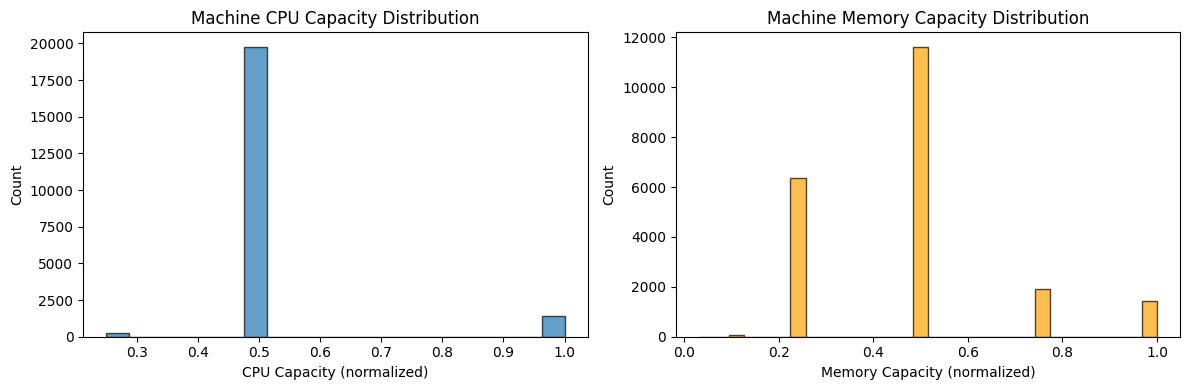

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(machines_df['cpu'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('CPU Capacity (normalized)')
axes[0].set_ylabel('Count')
axes[0].set_title('Machine CPU Capacity Distribution')

axes[1].hist(machines_df['mem'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Memory Capacity (normalized)')
axes[1].set_ylabel('Count')
axes[1].set_title('Machine Memory Capacity Distribution')

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'notebooks' / 'machine_capacity_dist.png'), dpi=150)
plt.show()

In [7]:
# Load task events (sample first 10 files for exploration)
task_files = sorted(glob.glob(str(DATA_DIR / "task_events" / "*.csv.gz")))[:10]

tasks_data = []
for f in tqdm(task_files, desc="Parsing task events"):
    with gzip.open(f, 'rt') as fh:
        for line in fh:
            parts = line.strip().split(',')
            if len(parts) < 12:
                continue
            cpu = float(parts[9]) if parts[9] else 0
            mem = float(parts[10]) if parts[10] else 0
            disk = float(parts[11]) if parts[11] else 0
            evt = int(parts[5]) if parts[5] else -1
            if cpu > 0 and evt == 0:  # SUBMIT events with resource requests
                tasks_data.append({
                    'job_id': parts[2],
                    'task_idx': int(parts[3]) if parts[3] else 0,
                    'cpu': cpu,
                    'mem': mem,
                    'disk': disk,
                    'priority': int(parts[8]) if parts[8] else 0,
                    'sched_class': int(parts[7]) if parts[7] else 0,
                })

tasks_df = pd.DataFrame(tasks_data)
print(f"Tasks with resource requests (from first 10 files): {len(tasks_df)}")
print(f"Unique jobs: {tasks_df['job_id'].nunique()}")
print(f"\nResource request distributions:")
print(tasks_df[['cpu', 'mem', 'disk']].describe())

Parsing task events: 100%|██████████| 10/10 [00:03<00:00,  2.59it/s]


Tasks with resource requests (from first 10 files): 673120
Unique jobs: 13179

Resource request distributions:
                 cpu            mem           disk
count  673120.000000  673120.000000  673120.000000
mean        0.037697       0.030191       0.000348
std         0.036928       0.031389       0.000917
min         0.000625       0.000000       0.000000
25%         0.012500       0.013170       0.000038
50%         0.024990       0.020690       0.000216
75%         0.062500       0.033390       0.000404
max         0.500000       0.955100       0.011310


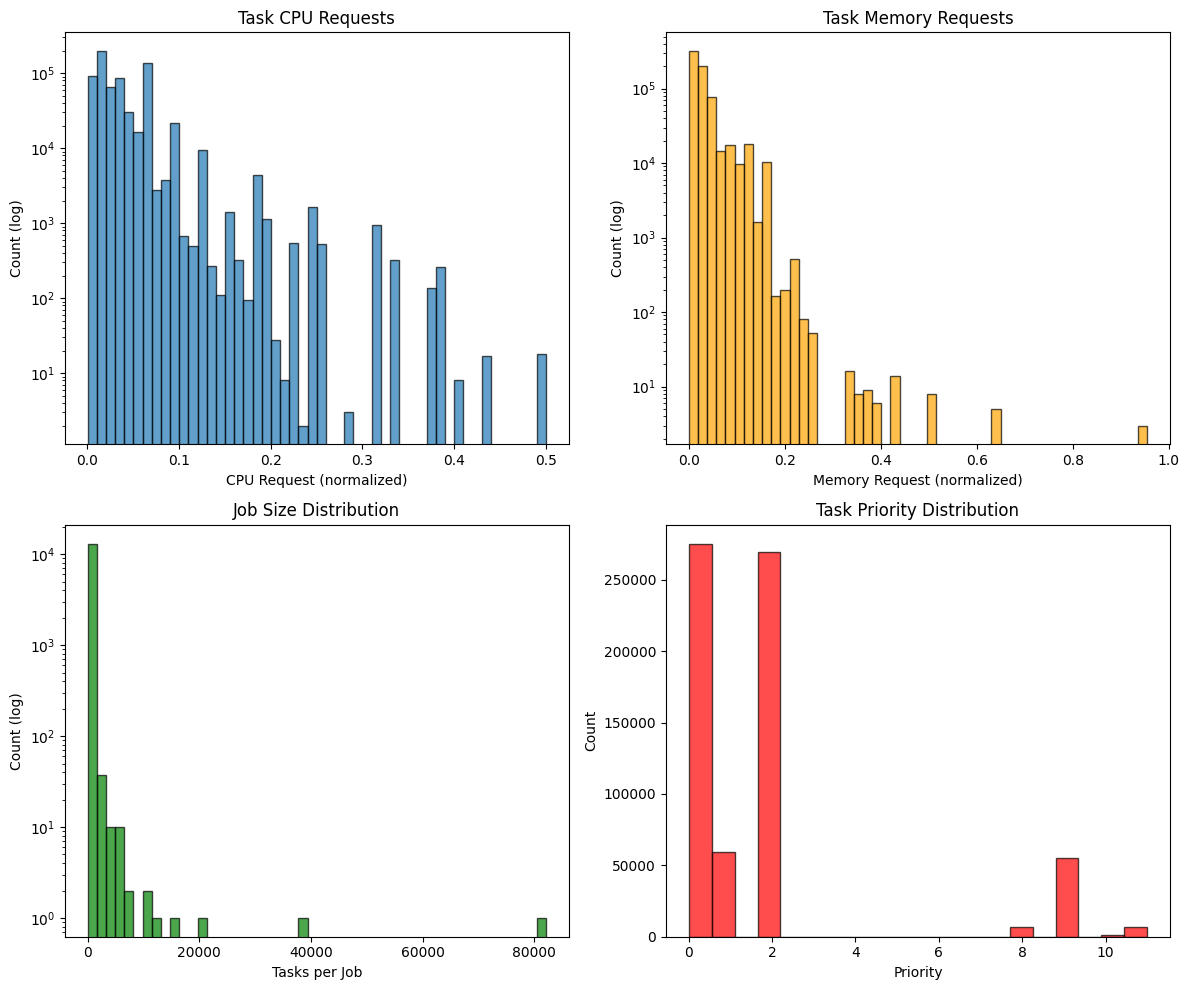


Tasks per job stats:
count    13179.000000
mean        51.075195
std        874.758416
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max      82105.000000
dtype: float64


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# CPU requests
axes[0, 0].hist(tasks_df['cpu'], bins=50, edgecolor='black', alpha=0.7, log=True)
axes[0, 0].set_xlabel('CPU Request (normalized)')
axes[0, 0].set_ylabel('Count (log)')
axes[0, 0].set_title('Task CPU Requests')

# Memory requests
axes[0, 1].hist(tasks_df['mem'], bins=50, edgecolor='black', alpha=0.7, color='orange', log=True)
axes[0, 1].set_xlabel('Memory Request (normalized)')
axes[0, 1].set_ylabel('Count (log)')
axes[0, 1].set_title('Task Memory Requests')

# Tasks per job
tasks_per_job = tasks_df.groupby('job_id').size()
axes[1, 0].hist(tasks_per_job, bins=50, edgecolor='black', alpha=0.7, color='green', log=True)
axes[1, 0].set_xlabel('Tasks per Job')
axes[1, 0].set_ylabel('Count (log)')
axes[1, 0].set_title('Job Size Distribution')

# Priority distribution
axes[1, 1].hist(tasks_df['priority'], bins=20, edgecolor='black', alpha=0.7, color='red')
axes[1, 1].set_xlabel('Priority')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Task Priority Distribution')

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'notebooks' / 'task_distributions.png'), dpi=150)
plt.show()

print(f"\nTasks per job stats:")
print(tasks_per_job.describe())

## 4. Load Trace Data into PF-MPPO Pipeline

Use the `GoogleTraceDataset` loader to parse the trace and generate training episodes.

In [9]:
from ml.scheduler.pfmppo.google_trace_loader import GoogleTraceDataset, generate_trace_dag

# Load the full trace dataset
dataset = GoogleTraceDataset(
    data_dir=str(DATA_DIR),
    max_tasks_per_episode=30,
    max_jobs_per_episode=8,
    min_tasks_per_job=2,
).load()

stats = dataset.stats()
print("Trace Dataset Statistics:")
for k, v in stats.items():
    print(f"  {k}: {v}")

Loading Google Cluster Trace from c:\Users\udit2\OneDrive\Desktop\BTP\data (max_files=10)...
  Loaded 12460 machines
  Parsing task_events file 1/10...
  Parsing task_events file 5/10...
  Parsing task_events file 10/10...
  Loaded 3759 jobs (453279 tasks)
Trace Dataset Statistics:
  num_jobs: 3759
  num_machines: 12460
  total_tasks: 453279
  median_duration_s: 371.864585
  median_cpu_request: 0.03125
  median_mem_request: 0.02545
  tasks_per_job_avg: 120.58499600957701


In [10]:
# Generate a few sample episodes and visualize
rng = np.random.default_rng(42)

episode_stats = []
for i in range(20):
    dag, vms = dataset.sample_episode(rng)
    tasks = dag.get_all_tasks()
    episode_stats.append({
        'num_tasks': dag.num_tasks(),
        'num_vms': len(vms),
        'avg_cpu': np.mean([t.req_cpu for t in tasks]),
        'avg_mem': np.mean([t.req_mem for t in tasks]),
        'avg_duration': np.mean([t.t_dur for t in tasks]),
        'max_duration': max(t.t_dur for t in tasks),
    })

ep_df = pd.DataFrame(episode_stats)
print("Sample Episode Statistics (20 episodes):")
print(ep_df.describe())

Sample Episode Statistics (20 episodes):
       num_tasks  num_vms    avg_cpu       avg_mem  avg_duration  max_duration
count       20.0     20.0  20.000000     20.000000     20.000000     20.000000
mean        30.0      4.0   1.358002   4334.189745    594.651841    798.987530
std          0.0      0.0   1.618283   6634.695974    862.634669   1003.817871
min         30.0      4.0   0.336545    325.976064    207.930299    371.864585
25%         30.0      4.0   0.441615    998.498850    267.517720    371.864585
50%         30.0      4.0   0.608253   2056.873574    362.782205    371.864585
75%         30.0      4.0   1.630920   4263.686963    371.864585    457.398142
max         30.0      4.0   7.100800  28350.873600   3461.473076   3600.000000


## 5. Training on Google Cluster Trace

Train the PF-MPPO scheduler using real trace data.

In [11]:
from ml.scheduler.pfmppo.multi_agent import CTDETrainer
from ml.scheduler.pfmppo.dag_generator import load_vm_configs

# Training configuration
CONFIG_PATH = str(PROJECT_ROOT / "ml" / "scheduler" / "pfmppo" / "configs" / "4_nodes.json")
vm_configs = load_vm_configs(CONFIG_PATH)

TRAIN_CONFIG = {
    "num_tasks": 30,
    "num_vms": len(vm_configs),
    "k_pairs": 10,
    "max_steps": 200,
    "max_deps_per_task": 3,
    "vm_configs": vm_configs,
    "seed": 42,
    "dag_mode": "trace",
    "data_dir": str(DATA_DIR),
    "num_workspaces": (3, 8),
    "template_ratio": 0.7,
}

print("Training config:")
for k, v in TRAIN_CONFIG.items():
    if k != 'vm_configs':
        print(f"  {k}: {v}")
print(f"  vm_configs: {len(vm_configs)} VMs")

Training config:
  num_tasks: 30
  num_vms: 4
  k_pairs: 10
  max_steps: 200
  max_deps_per_task: 3
  seed: 42
  dag_mode: trace
  data_dir: c:\Users\udit2\OneDrive\Desktop\BTP\data
  num_workspaces: (3, 8)
  template_ratio: 0.7
  vm_configs: 4 VMs


In [ ]:
# Train on trace data
ITERATIONS = 2000
BATCH_SIZE = 1000
LR = 0.003

trainer_trace = CTDETrainer(
    num_workers=4,
    env_config=TRAIN_CONFIG,
    k_pairs=10,
    lr=LR,
    gamma=0.8,
    epsilon=0.2,
    batch_size=BATCH_SIZE,
    update_epochs=4,
    mini_batch_size=64,
)

print(f"Starting training: {ITERATIONS} iterations, {BATCH_SIZE} batch size, LR={LR}")
print("="*60)
metrics_trace = trainer_trace.train(iterations=ITERATIONS, log_interval=50)
print("="*60)
print("Training complete!")

Starting training: 500 iterations, 1000 batch size, LR=0.001
[Iter 50/500] actor_loss=0.0016 critic_loss=2013.0319 entropy=1.9567 mean_reward=-41.5026
[Iter 100/500] actor_loss=-0.0019 critic_loss=1918.5053 entropy=1.8873 mean_reward=-41.0901
[Iter 150/500] actor_loss=0.0006 critic_loss=1817.6616 entropy=1.8309 mean_reward=-39.8105
[Iter 200/500] actor_loss=0.0008 critic_loss=2019.2563 entropy=1.8826 mean_reward=-40.6285
[Iter 250/500] actor_loss=-0.0006 critic_loss=1915.1903 entropy=1.8825 mean_reward=-40.0538
[Iter 300/500] actor_loss=-0.0006 critic_loss=1925.8963 entropy=1.8201 mean_reward=-39.7122
[Iter 350/500] actor_loss=0.0001 critic_loss=1813.2617 entropy=1.9076 mean_reward=-40.7774
[Iter 400/500] actor_loss=0.0016 critic_loss=1771.2363 entropy=1.8219 mean_reward=-39.4791
[Iter 450/500] actor_loss=-0.0017 critic_loss=2047.1219 entropy=1.8017 mean_reward=-39.0108
[Iter 500/500] actor_loss=-0.0053 critic_loss=1941.2675 entropy=1.8208 mean_reward=-38.9573
Training complete!


In [13]:
# Save model
SAVE_DIR = PROJECT_ROOT / "runs" / "pfmppo_trace"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
trainer_trace.save(str(SAVE_DIR / "model.pt"))
print(f"Model saved to {SAVE_DIR / 'model.pt'}")

Model saved to c:\Users\udit2\OneDrive\Desktop\BTP\runs\pfmppo_trace\model.pt


## 6. Training Curves

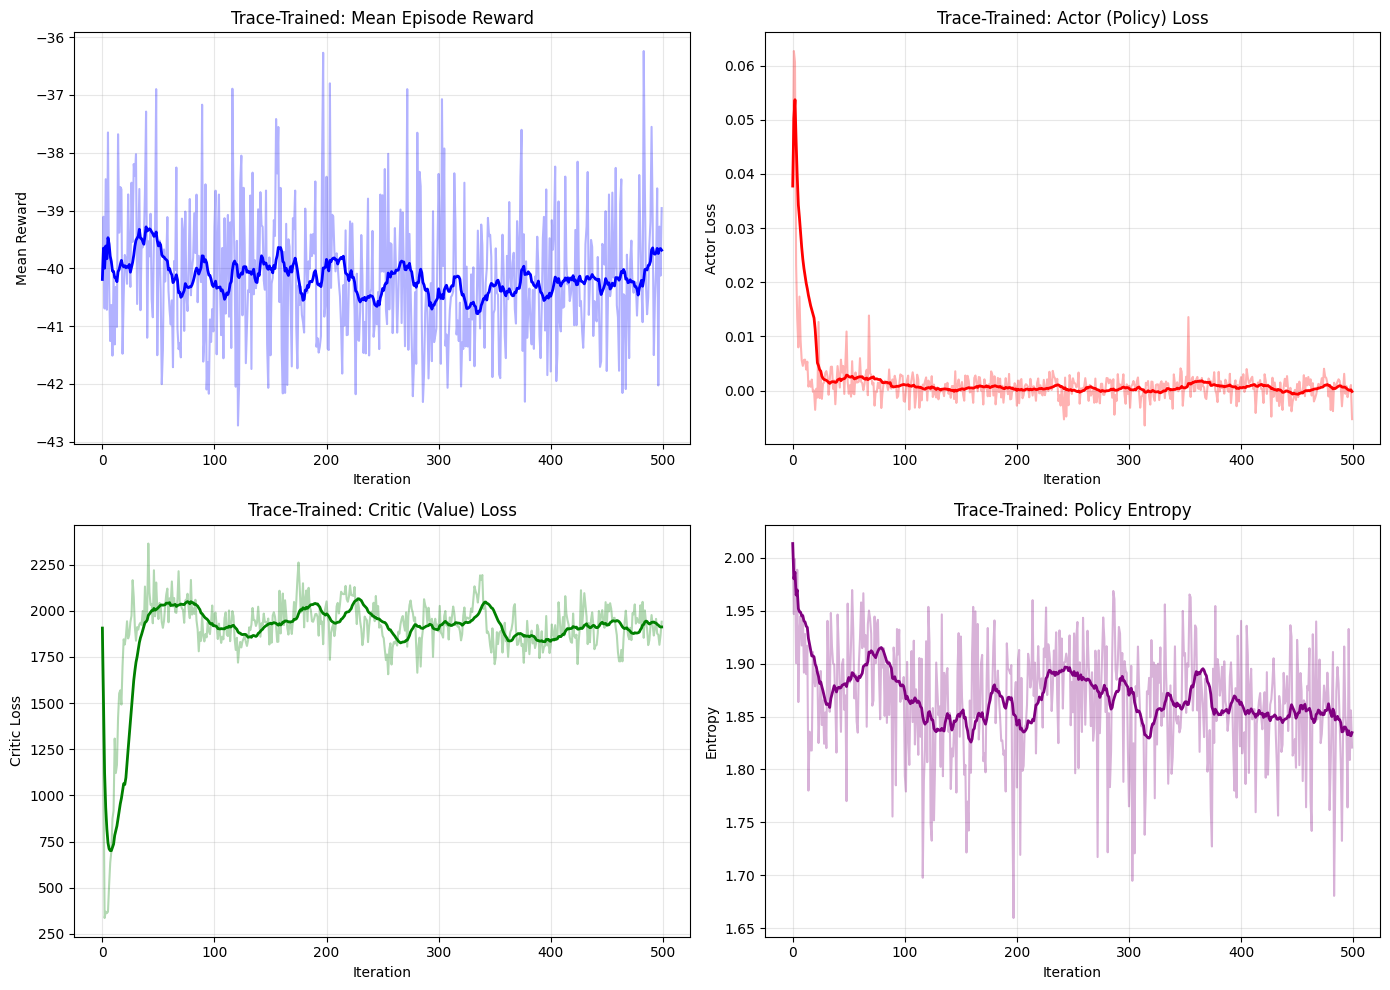

In [14]:
def plot_training_curves(metrics, title_prefix=""):
    """Plot actor loss, critic loss, entropy, and mean reward."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Smooth with rolling window
    def smooth(y, window=20):
        if len(y) < window:
            return y
        return pd.Series(y).rolling(window, min_periods=1).mean().values
    
    # Mean Reward
    ax = axes[0, 0]
    rewards = metrics['mean_reward']
    ax.plot(rewards, alpha=0.3, color='blue')
    ax.plot(smooth(rewards), color='blue', linewidth=2)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Mean Reward')
    ax.set_title(f'{title_prefix}Mean Episode Reward')
    ax.grid(True, alpha=0.3)
    
    # Actor Loss
    ax = axes[0, 1]
    al = metrics['actor_loss']
    ax.plot(al, alpha=0.3, color='red')
    ax.plot(smooth(al), color='red', linewidth=2)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Actor Loss')
    ax.set_title(f'{title_prefix}Actor (Policy) Loss')
    ax.grid(True, alpha=0.3)
    
    # Critic Loss
    ax = axes[1, 0]
    cl = metrics['critic_loss']
    ax.plot(cl, alpha=0.3, color='green')
    ax.plot(smooth(cl), color='green', linewidth=2)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Critic Loss')
    ax.set_title(f'{title_prefix}Critic (Value) Loss')
    ax.grid(True, alpha=0.3)
    
    # Entropy
    ax = axes[1, 1]
    ent = metrics['entropy']
    ax.plot(ent, alpha=0.3, color='purple')
    ax.plot(smooth(ent), color='purple', linewidth=2)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Entropy')
    ax.set_title(f'{title_prefix}Policy Entropy')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

fig = plot_training_curves(metrics_trace, "Trace-Trained: ")
fig.savefig(str(PROJECT_ROOT / 'notebooks' / 'trace_training_curves.png'), dpi=150)
plt.show()

## 7. Comparison: Trace vs Random DAG Training

Train a baseline model on random synthetic DAGs and compare.

In [15]:
# Train baseline on random DAGs
BASELINE_CONFIG = TRAIN_CONFIG.copy()
BASELINE_CONFIG["dag_mode"] = "random"
BASELINE_CONFIG["data_dir"] = None

trainer_random = CTDETrainer(
    num_workers=4,
    env_config=BASELINE_CONFIG,
    k_pairs=10,
    lr=LR,
    gamma=0.9,
    epsilon=0.2,
    batch_size=BATCH_SIZE,
    update_epochs=4,
    mini_batch_size=64,
)

print(f"Training baseline (random DAGs): {ITERATIONS} iterations")
print("="*60)
metrics_random = trainer_random.train(iterations=ITERATIONS, log_interval=50)
print("="*60)
print("Baseline training complete!")

trainer_random.save(str(SAVE_DIR / "model_random_baseline.pt"))

Training baseline (random DAGs): 500 iterations
[Iter 50/500] actor_loss=-0.0040 critic_loss=1946.0483 entropy=1.9185 mean_reward=-42.1147
[Iter 100/500] actor_loss=-0.0039 critic_loss=2049.7124 entropy=1.8647 mean_reward=-40.9664
[Iter 150/500] actor_loss=-0.0001 critic_loss=1931.4628 entropy=1.8935 mean_reward=-41.6758
[Iter 200/500] actor_loss=0.0019 critic_loss=1906.5849 entropy=1.8651 mean_reward=-40.9762
[Iter 250/500] actor_loss=-0.0024 critic_loss=1912.2146 entropy=1.8378 mean_reward=-40.4980
[Iter 300/500] actor_loss=-0.0003 critic_loss=1840.9032 entropy=1.6704 mean_reward=-36.9281
[Iter 350/500] actor_loss=0.0001 critic_loss=1901.6411 entropy=1.8649 mean_reward=-40.3626
[Iter 400/500] actor_loss=0.0009 critic_loss=1936.8990 entropy=1.9120 mean_reward=-40.7444
[Iter 450/500] actor_loss=0.0037 critic_loss=1844.4038 entropy=1.8916 mean_reward=-40.1836
[Iter 500/500] actor_loss=0.0022 critic_loss=1726.5666 entropy=1.8588 mean_reward=-40.8964
Baseline training complete!


C:\Users\udit2\AppData\Local\Temp\ipykernel_1072\2587736578.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([trace_final, random_final], labels=['Trace', 'Random'])


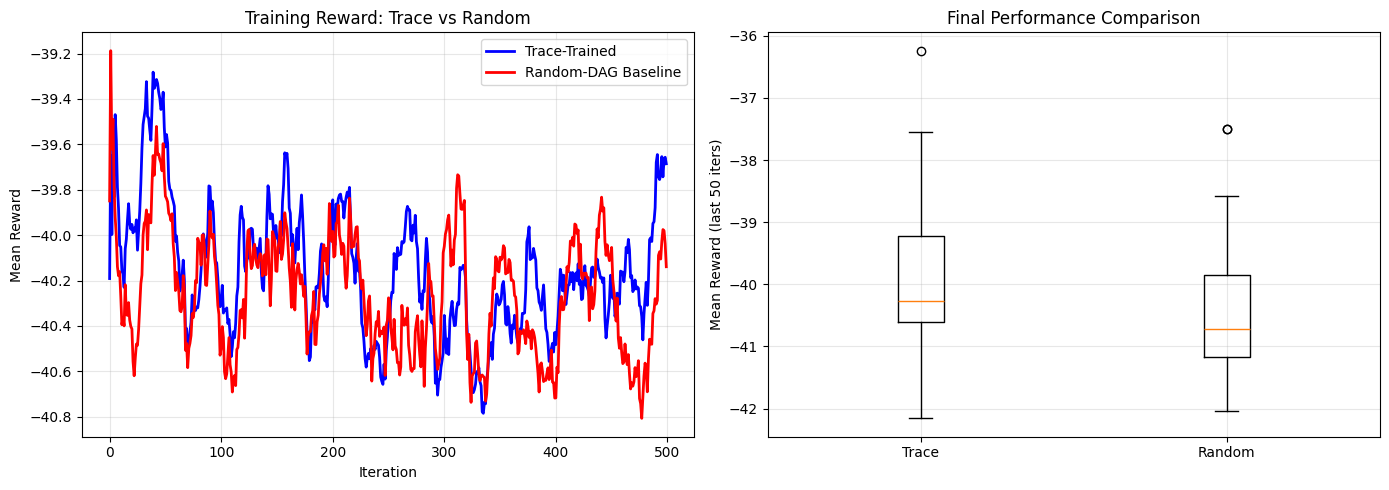


Final mean reward (last 50 iterations):
  Trace-trained:  -40.0068 ± 1.1853
  Random baseline: -40.4130 ± 1.0587


In [16]:
# Comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def smooth(y, window=20):
    return pd.Series(y).rolling(window, min_periods=1).mean().values

# Reward comparison
ax = axes[0]
ax.plot(smooth(metrics_trace['mean_reward']), label='Trace-Trained', color='blue', linewidth=2)
ax.plot(smooth(metrics_random['mean_reward']), label='Random-DAG Baseline', color='red', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean Reward')
ax.set_title('Training Reward: Trace vs Random')
ax.legend()
ax.grid(True, alpha=0.3)

# Final reward distribution
ax = axes[1]
last_n = 50
trace_final = metrics_trace['mean_reward'][-last_n:]
random_final = metrics_random['mean_reward'][-last_n:]
ax.boxplot([trace_final, random_final], labels=['Trace', 'Random'])
ax.set_ylabel('Mean Reward (last 50 iters)')
ax.set_title('Final Performance Comparison')
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(str(PROJECT_ROOT / 'notebooks' / 'trace_vs_random_comparison.png'), dpi=150)
plt.show()

print(f"\nFinal mean reward (last {last_n} iterations):")
print(f"  Trace-trained:  {np.mean(trace_final):.4f} ± {np.std(trace_final):.4f}")
print(f"  Random baseline: {np.mean(random_final):.4f} ± {np.std(random_final):.4f}")

## 8. Evaluation on Trace Episodes

Evaluate both models on held-out trace episodes to measure generalization.

In [17]:
from ml.scheduler.pfmppo.env import PFMPPOEnv

def evaluate_model(trainer, env_config, n_episodes=50, seed=999):
    """Evaluate a trained model on multiple episodes."""
    env = PFMPPOEnv(**env_config)
    rewards_per_episode = []

    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        total_reward = 0
        done = False

        while not done:
            action, _, _ = trainer.global_agent.select_action(
                obs, valid_mask=info.get('valid_mask'), deterministic=True
            )
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = terminated or truncated

        rewards_per_episode.append(total_reward)

    return rewards_per_episode

# Evaluate on trace episodes
eval_config = TRAIN_CONFIG.copy()
eval_config['seed'] = None  # Let reset() handle seeds

print("Evaluating trace-trained model on trace episodes...")
trace_eval_rewards = evaluate_model(trainer_trace, eval_config, n_episodes=50)

print("Evaluating random-trained model on trace episodes...")
random_eval_rewards = evaluate_model(trainer_random, eval_config, n_episodes=50)

print(f"\nEvaluation Results (50 trace episodes):")
print(f"  Trace-trained:  mean={np.mean(trace_eval_rewards):.4f}, std={np.std(trace_eval_rewards):.4f}")
print(f"  Random-trained: mean={np.mean(random_eval_rewards):.4f}, std={np.std(random_eval_rewards):.4f}")

Evaluating trace-trained model on trace episodes...
Loading Google Cluster Trace from c:\Users\udit2\OneDrive\Desktop\BTP\data (max_files=10)...
  Loaded 12460 machines
  Parsing task_events file 1/10...
  Parsing task_events file 5/10...
  Parsing task_events file 10/10...
  Loaded 3759 jobs (453279 tasks)
Evaluating random-trained model on trace episodes...
Loading Google Cluster Trace from c:\Users\udit2\OneDrive\Desktop\BTP\data (max_files=10)...
  Loaded 12460 machines
  Parsing task_events file 1/10...
  Parsing task_events file 5/10...
  Parsing task_events file 10/10...
  Loaded 3759 jobs (453279 tasks)

Evaluation Results (50 trace episodes):
  Trace-trained:  mean=-7910.7850, std=1535.2798
  Random-trained: mean=-7823.8037, std=1576.4961


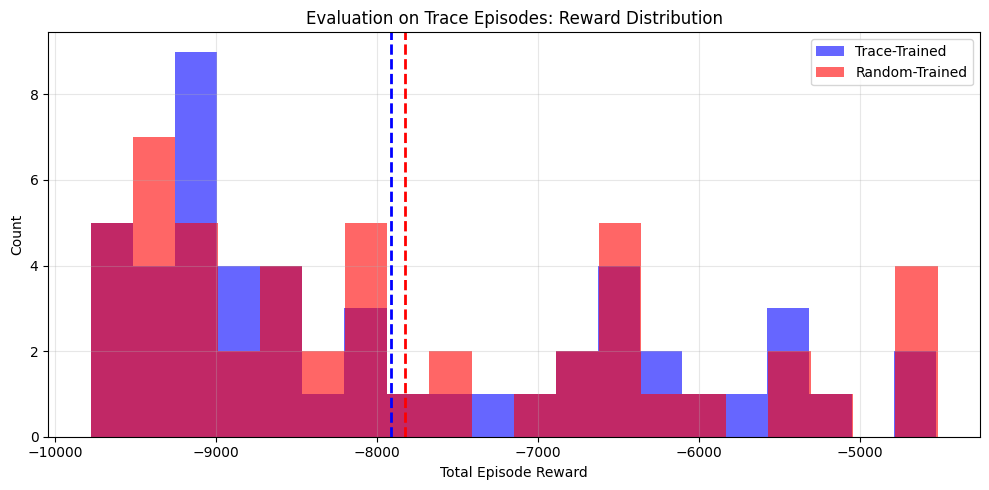

In [18]:
# Evaluation reward distribution plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(trace_eval_rewards, bins=20, alpha=0.6, label='Trace-Trained', color='blue')
ax.hist(random_eval_rewards, bins=20, alpha=0.6, label='Random-Trained', color='red')
ax.axvline(np.mean(trace_eval_rewards), color='blue', linestyle='--', linewidth=2)
ax.axvline(np.mean(random_eval_rewards), color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Total Episode Reward')
ax.set_ylabel('Count')
ax.set_title('Evaluation on Trace Episodes: Reward Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(str(PROJECT_ROOT / 'notebooks' / 'evaluation_distribution.png'), dpi=150)
plt.show()

## 9. Summary

| Metric | Trace-Trained | Random Baseline |
|--------|--------------|----------------|
| Final Training Reward | see above | see above |
| Eval on Trace Episodes | see above | see above |

The trace-trained model should perform significantly better on trace episodes because it has learned the real resource request distributions and job structure patterns from Google's production workload.